# Bài tập Chương 1

## 1. Cài đặt các thư viện OpenCV va Pillow

In [1]:
# Bài 1: Kiểm tra cài đặt OpenCV, Pillow và NumPy
import cv2
import numpy as np
import PIL
from PIL import Image


print("=" * 50)
print("KIỂM TRA CÀI ĐẶT THƯ VIỆN XỬ LÝ ẢNH")
print("=" * 50)

print(f"\n✅ OpenCV version: {cv2.__version__}")
print(f"✅ NumPy version: {np.__version__}")
print(f"✅ Pillow version: {PIL.__version__}")

print("\n🎉 Tất cả thư viện đã được cài đặt thành công!")
print("=" * 50)

KIỂM TRA CÀI ĐẶT THƯ VIỆN XỬ LÝ ẢNH

✅ OpenCV version: 4.13.0
✅ NumPy version: 2.4.6
✅ Pillow version: 12.2.0

🎉 Tất cả thư viện đã được cài đặt thành công!


## 2. Đọc và hiển thị ảnh:

In [5]:
import os
import matplotlib.pyplot as plt

# Thiết lập đường dẫn
INPUT_PATH = os.path.abspath("../images/sample_image.png")
OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("✅ Đã thiết lập xong môi trường!")

✅ Đã thiết lập xong môi trường!


- Đọc một hình ảnh bất kỳ từ máy tính.

In [6]:
# Đọc ảnh bằng OpenCV và Pillow
img_cv = cv2.imread(INPUT_PATH)
img_pil = Image.open(INPUT_PATH)

# Kiểm tra dữ liệu
if img_cv is not None:
    print(f"📖 [OpenCV] Kích thước: {img_cv.shape}")
    print(f"📖 [Pillow] Kích thước: {img_pil.size}")
else:
    print("❌ Lỗi: Không tìm thấy file ảnh!")

📖 [OpenCV] Kích thước: (1024, 1024, 3)
📖 [Pillow] Kích thước: (1024, 1024)


- Hiển thị hình ảnh đó lên màn hình.

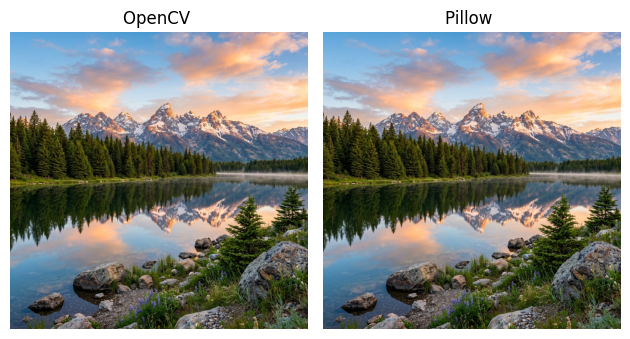

In [7]:
# 1. Hiển thị ảnh từ OpenCV (cần chuyển đổi BGR -> RGB)
img_cv_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)

# 2. Hiển thị ảnh từ Pillow (PIL thường là RGB mặc định)
# Nếu ảnh Pillow là ảnh xám hoặc CMYK, cần chuyển về RGB
img_pil_rgb = img_pil.convert('RGB')

# Ảnh OpenCV
plt.subplot(1, 2, 1)
plt.imshow(img_cv_rgb)
plt.title("OpenCV ")
plt.axis('off')

# Ảnh Pillow
plt.subplot(1, 2, 2)
plt.imshow(img_pil_rgb)
plt.title("Pillow ")
plt.axis('off')

plt.tight_layout()
plt.show()

- Lưu ảnh sang các định dạng khác

In [8]:
# Lưu bằng OpenCV
cv2.imwrite(os.path.join(OUTPUT_DIR, "output_opencv.jpg"), img_cv)
cv2.imwrite(os.path.join(OUTPUT_DIR, "output_opencv.bmp"), img_cv)

# Lưu bằng Pillow
img_pil.convert("RGB").save(os.path.join(OUTPUT_DIR, "output_pillow.jpg"), "JPEG")
img_pil.convert("RGB").save(os.path.join(OUTPUT_DIR, "output_pillow.bmp"), "BMP")

print(f"💾 Đã lưu ảnh vào thư mục: {OUTPUT_DIR}")

💾 Đã lưu ảnh vào thư mục: output


## 3. Chuyển đổi không gian màu:

In [9]:
print("✅ Đã load ảnh thành công!")

✅ Đã load ảnh thành công!


- Chuyển đổi ảnh từ RGB sang Grayscale

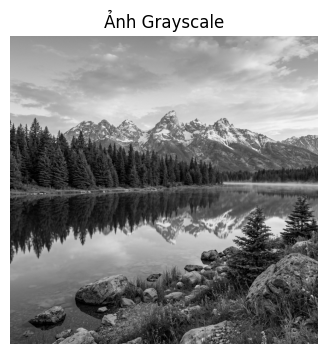

In [10]:
# Chuyển đổi từ BGR sang Gray
img_bgr = cv2.imread(INPUT_PATH)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# Hiển thị
plt.figure(figsize=(6, 4))
plt.imshow(img_gray, cmap='gray')
plt.title("Ảnh Grayscale")
plt.axis('off')
plt.show()

- Chuyển đổi ảnh sang các không gian màu khác như HSV, LAB

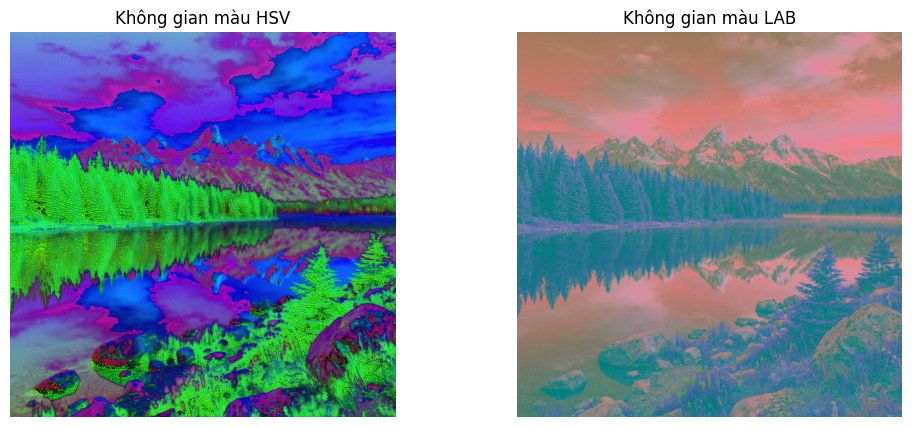

In [11]:
# Chuyển đổi không gian màu
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)

# Hiển thị so sánh
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_hsv)
plt.title("Không gian màu HSV")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_lab)
plt.title("Không gian màu LAB")
plt.axis('off')

plt.show()

## 4. Cắt xén và thay đổi kích thước:


- Cắt một vùng hình ảnh bất kỳ.

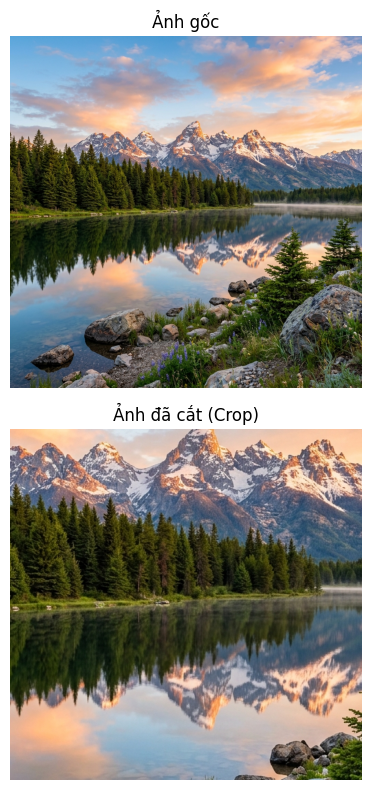

In [12]:
# Cắt vùng trung tâm (50% ảnh)
h, w = img_bgr.shape[:2]
img_crop = img_bgr[h//4 : 3*h//4, w//4 : 3*w//4]
img_crop_rgb = cv2.cvtColor(img_crop, cv2.COLOR_BGR2RGB)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 8))
# Ảnh gốc
plt.subplot(2, 1, 1)
plt.imshow(img_rgb)
plt.title("Ảnh gốc")
plt.axis('off')

# Ảnh sau khi cắt
plt.subplot(2, 1, 2)
plt.imshow(img_crop_rgb)
plt.title("Ảnh đã cắt (Crop)")
plt.axis('off')

plt.tight_layout()
plt.show()

- Thay đổi kích thước hình ảnh theo tỷ lệ 

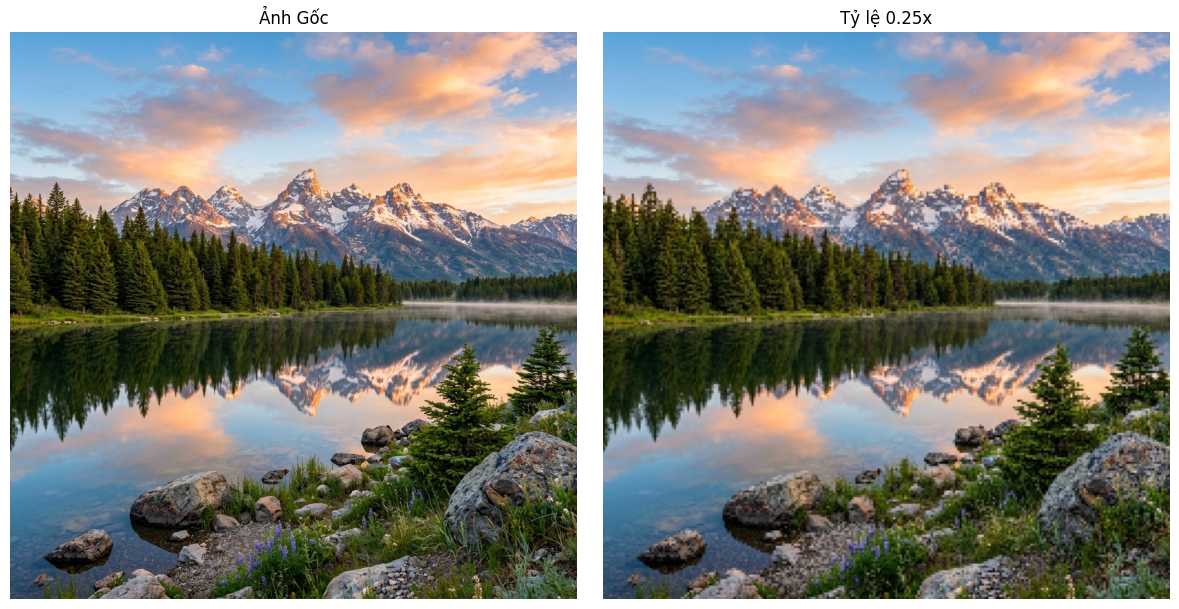

In [13]:
# 1. Tính toán ảnh scale 0.25x
scale = 0.25
new_w, new_h = int(w * scale), int(h * scale)
img_scaled = cv2.resize(img_cv, (new_w, new_h), interpolation=cv2.INTER_LINEAR)

# 2. Thiết lập hiển thị so sánh (1 hàng, 2 cột)
plt.figure(figsize=(12, 6))

# Ảnh gốc
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB))
plt.title(f"Ảnh Gốc")
plt.axis('off')

# Ảnh Scale 0.25x
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(img_scaled, cv2.COLOR_BGR2RGB))
plt.title(f"Tỷ lệ {scale}x")
plt.axis('off')

plt.tight_layout()
plt.show()

- Thay đổi kích thước theo kích thước cố định (resize)

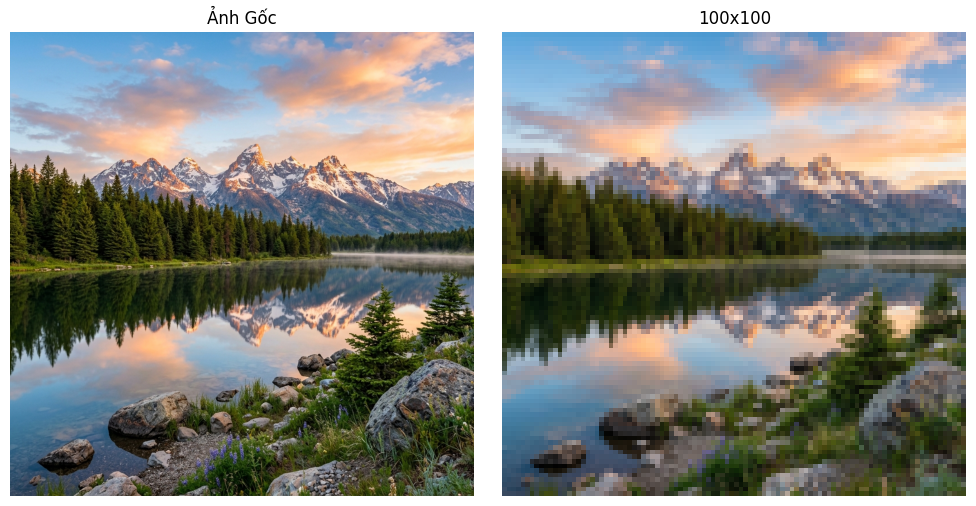

In [14]:
# Thiết lập lưới hiển thị: 1 hàng, 2 cột
plt.figure(figsize=(10, 5))

# 1. Ảnh gốc
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB))
plt.title(f"Ảnh Gốc")
plt.axis('off')

# 2. Ảnh Fixed 100x100
img_fixed = cv2.resize(img_cv, (100, 100), interpolation=cv2.INTER_AREA)

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(img_fixed, cv2.COLOR_BGR2RGB))
plt.title(f"100x100")
plt.axis('off')

plt.tight_layout()
plt.show()

## 5 .Vẽ hình cơ bản:


- Vẽ các hình cơ bản như đường thẳng, hình tròn, hình chữ nhật lên hình ảnh.

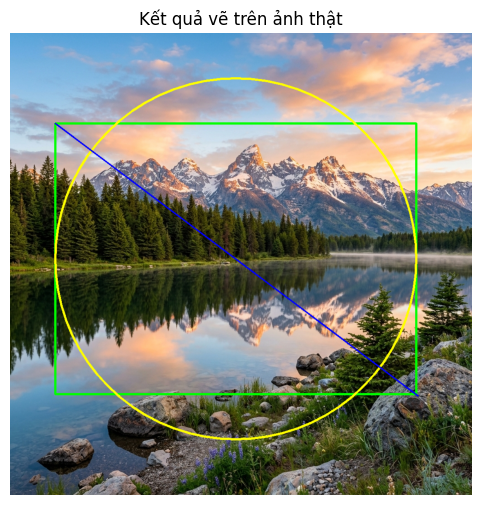

✅ Đã lưu ảnh vào thư mục output.


In [15]:


def display_image(img, title="Image"):
    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()
    
if img_cv is None:
    print("❌ Lỗi: Không thể tải ảnh. Kiểm tra lại đường dẫn!")
else:
    # Sao chép ảnh để vẽ
    img_draw = img_cv.copy()
    
    # 1. Vẽ hình chữ nhật
    cv2.rectangle(img_draw, (900, 800), (100, 200), (0, 255, 0), 3)
    
    # 2. Vẽ hình tròn
    cv2.circle(img_draw, (500, 500), 400, (0, 500, 255), 3)
    
    # 3. Vẽ đường thẳng
    cv2.line(img_draw, (100, 200), (img_draw.shape[1] - 120, img_draw.shape[0] - 220), (255, 0, 0), 2)
    
    # Hiển thị
    display_image(img_draw, "Kết quả vẽ trên ảnh thật")
    
    # Lưu kết quả
    cv2.imwrite(os.path.join(OUTPUT_DIR, "final_drawing.jpg"), img_draw)
    print("✅ Đã lưu ảnh vào thư mục output.")

- Thêm văn bản (Text) vào hình ảnh

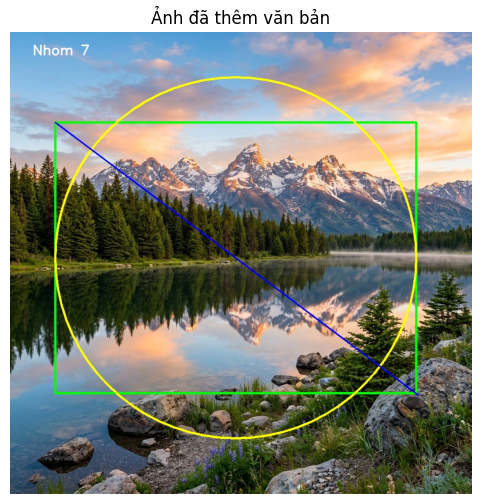

In [16]:
import cv2
import os

# 1. Đọc lại bức ảnh đã được vẽ ở bước trước
# Đảm bảo đường dẫn này khớp với nơi bạn đã lưu 'final_drawing.jpg'
INPUT_IMAGE_PATH = os.path.join(OUTPUT_DIR, "final_drawing.jpg")
img_input = cv2.imread(INPUT_IMAGE_PATH)

if img_input is None:
    print("❌ Lỗi: Không tìm thấy ảnh 'final_drawing.jpg'. Hãy kiểm tra lại thư mục output!")
else:
    # 2. Sao chép ảnh để xử lý
    img_with_text = img_input.copy()
    
    # 3. Thêm văn bản
    text = "Nhom 7"
    position = (50, 50) # Tọa độ góc dưới bên trái của chữ
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 1.0
    color = (255, 255, 255) # Màu trắng
    thickness = 2
    
    # Vẽ văn bản lên ảnh
    cv2.putText(img_with_text, text, position, font, font_scale, color, thickness, cv2.LINE_AA)
    
    # 4. Hiển thị kết quả
    display_image(img_with_text, "Ảnh đã thêm văn bản")
    
    # 5. Lưu lại thành file mới
    FINAL_OUTPUT_PATH = os.path.join(OUTPUT_DIR, "final_with_text.jpg")
    cv2.imwrite(FINAL_OUTPUT_PATH, img_with_text)
